In [15]:
import numpy as np
import pandas as pd  #to read and work with .csv files
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from nicegui import ui    #pip install nicegui



#file outline
#1)ask the user for input
#2) read the .csv file
#3) filter and adjust data based on users choice
#4) plot(plotly?, matplotlib? seaborn?)
#5) save the plot as html or png


#tools to use: NiceGUI for user input
#NiceGUI: provides interface for output of plot. variables for user to select for the plot, adn table display fo csv content.
#pandas for reading .csv files
#matplotlib/seaborn/plotly for plotting


In [16]:
df = pd.read_csv('supercon2_v22.12.03.csv')
data = pd.read_csv('supercon2_v22.12.03.csv', header=0)

data

#ask the user for input



,id,rawMaterial,materialId,name,formula,doping,shape,materialClass,fabrication,substrate,...,appliedPressure,section,subsection,hash,title,doi,authors,publisher,journal,year
0,61ba959a7c13e4f711c50c3e,InO x films,1.942078e+09,NaN,InO x,NaN,films,Oxides,NaN,NaN,...,NaN,body,figure,b7d13f231a,Infinite-randomness fixed point of the quantum...,10.1103/physrevb.99.054515,"Nicholas A Lewellyn, Ilana M Percher, J J Nels...",American Physical Society (APS),Physical Review B,2019.0
1,61ba959a0cb3d3a5e6c50c3e,"x = 0.04, 0.05, and 0.06)",1.064204e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,body,paragraph,67f5567e75,Tuning the interplay between nematicity and sp...,10.1038/s41467-018-04471-7,"S-H Baek, Dilip Bhoi, Woohyun Nam, Bumsung Lee...",Springer Science and Business Media LLC,Nature Communications,2018.0
2,61ba959a720b8b3d36c50c3e,amorphous In-O films,-1.411819e+09,NaN,In-O,NaN,films,Alloys,NaN,NaN,...,NaN,body,NaN,e74ca47303,Scaling analysis of the magnetic field-tuned q...,10.1134/1.568304,"V F Gantmakher, M V Golubkov, V T Dolgopolov, ...",Pleiades Publishing Ltd,Journal of Experimental and Theoretical Physic...,1998.0
3,61ba959a6a35f302ddc50c3e,x= 0.108,4.969883e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,body,figure,c8fb7503bc,Doping evolution of antiferromagnetism and tra...,NaN,"Rui Zhang, Dongliang Gong, Xingye Lu, Shiliang...",NaN,NaN,2015.0
4,61ba959a85b12ae79ac50c3e,PrRu 2 Si 2,-5.030707e+08,NaN,PrRu 2 Si 2,NaN,NaN,Alloys,NaN,NaN,...,NaN,header,abstract,e8285dd0b7,Crystal-field interactions in PrRu2Si2,10.1088/0953-8984/12/34/307,"R Michalski, Z Ropka, R J Radwanski",IOP Publishing,Journal of Physics: Condensed Matter,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40319,61ba9fbb3136e52869c51390,NbSe 2 nanobelts,1.325648e+09,NaN,NbSe 2,NaN,nanobelts,Chalcogenides,NaN,NaN,...,NaN,body,paragraph,7767ae827b,Magnetic switching of phase-slip dissipation i...,10.1103/physrevb.75.020501,"Abram Falk, Mandar M Deshmukh, Amy L Prieto, J...",American Physical Society (APS),Physical Review B,2007.0
40320,61ba9fbb0a416aa3d9c51367,MgB 2,1.438579e+09,NaN,MgB 2,NaN,NaN,"Alloys, Borides",NaN,NaN,...,NaN,body,paragraph,eb762175eb,Effects of Al doping on the structural and ele...,10.1103/physrevb.66.012511,"O De La Peña, A Aguayo, R De Coss",American Physical Society (APS),Physical Review B,2014.0
40321,61ba9fbcab9e3e9324c5138b,CaBi2,-1.219075e+09,NaN,CaBi2,NaN,NaN,Alloys,NaN,NaN,...,NaN,header,abstract,04bc481d97,Observation of topological surface state in a ...,NaN,"Gyanendra Dhakal, M Mofazzel Hosen, Ayana Ghos...",NaN,NaN,2019.0
40322,61ba9fbcab9e3e9324c5138c,single-crystalline CaBi 2,-2.079131e+09,NaN,CaBi 2,NaN,single-crystalline,Alloys,NaN,NaN,...,NaN,body,paragraph,04bc481d97,Observation of topological surface state in a ...,NaN,"Gyanendra Dhakal, M Mofazzel Hosen, Ayana Ghos...",NaN,NaN,2019.0


In [17]:
columns_select = ['id', 'rawMaterial', 'materialId','formula', 'materialClass', 'variables', 'appliedPressure', 'criticalTemperature']  # example
df = df[columns_select]

print(df.head())

                         id                rawMaterial    materialId  \
0  61ba959a7c13e4f711c50c3e                InO x films  1.942078e+09   
1  61ba959a0cb3d3a5e6c50c3e  x = 0.04, 0.05, and 0.06)  1.064204e+09   
2  61ba959a720b8b3d36c50c3e       amorphous In-O films -1.411819e+09   
3  61ba959a6a35f302ddc50c3e                   x= 0.108  4.969883e+08   
4  61ba959a85b12ae79ac50c3e                PrRu 2 Si 2 -5.030707e+08   

       formula materialClass           variables appliedPressure  \
0        InO x        Oxides                 NaN             NaN   
1          NaN           NaN  x=0.04, 0.05, 0.06             NaN   
2         In-O        Alloys                 NaN             NaN   
3          NaN           NaN             x=0.108             NaN   
4  PrRu 2 Si 2        Alloys                 NaN             NaN   

  criticalTemperature  
0               2.8 K  
1                 2 K  
2                 2 K  
3                20 K  
4                 14K  


/home/tiffany/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65374 (\N{FULLWIDTH TILDE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/tiffany/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


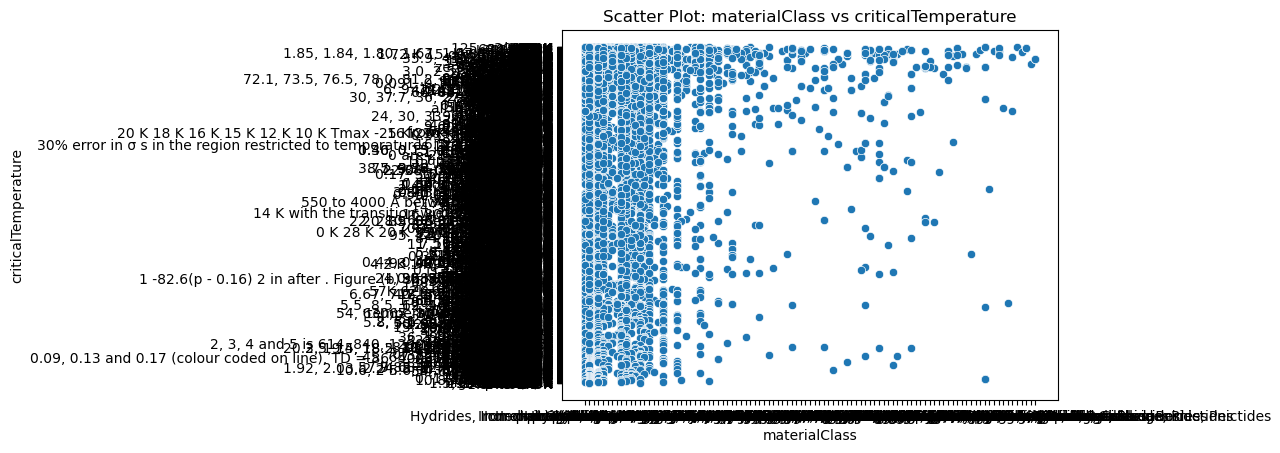

In [18]:
sns.scatterplot(
    data=df,
    x="materialClass",
    y="criticalTemperature",
    #hue="Air_Quality_Label",        #separate by label
    #palette= colors,                #to look up colors from dictionary 
)

plt.xlabel("materialClass")
plt.ylabel("criticalTemperature")
plt.title("Scatter Plot: materialClass vs criticalTemperature")
#plt.legend(title="Air Quality Class")
plt.show()

/tmp/ipykernel_18797/1365717443.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['formula_acronym'] = plot_data['formula'].apply(formula_to_acronym)
/tmp/ipykernel_18797/1365717443.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


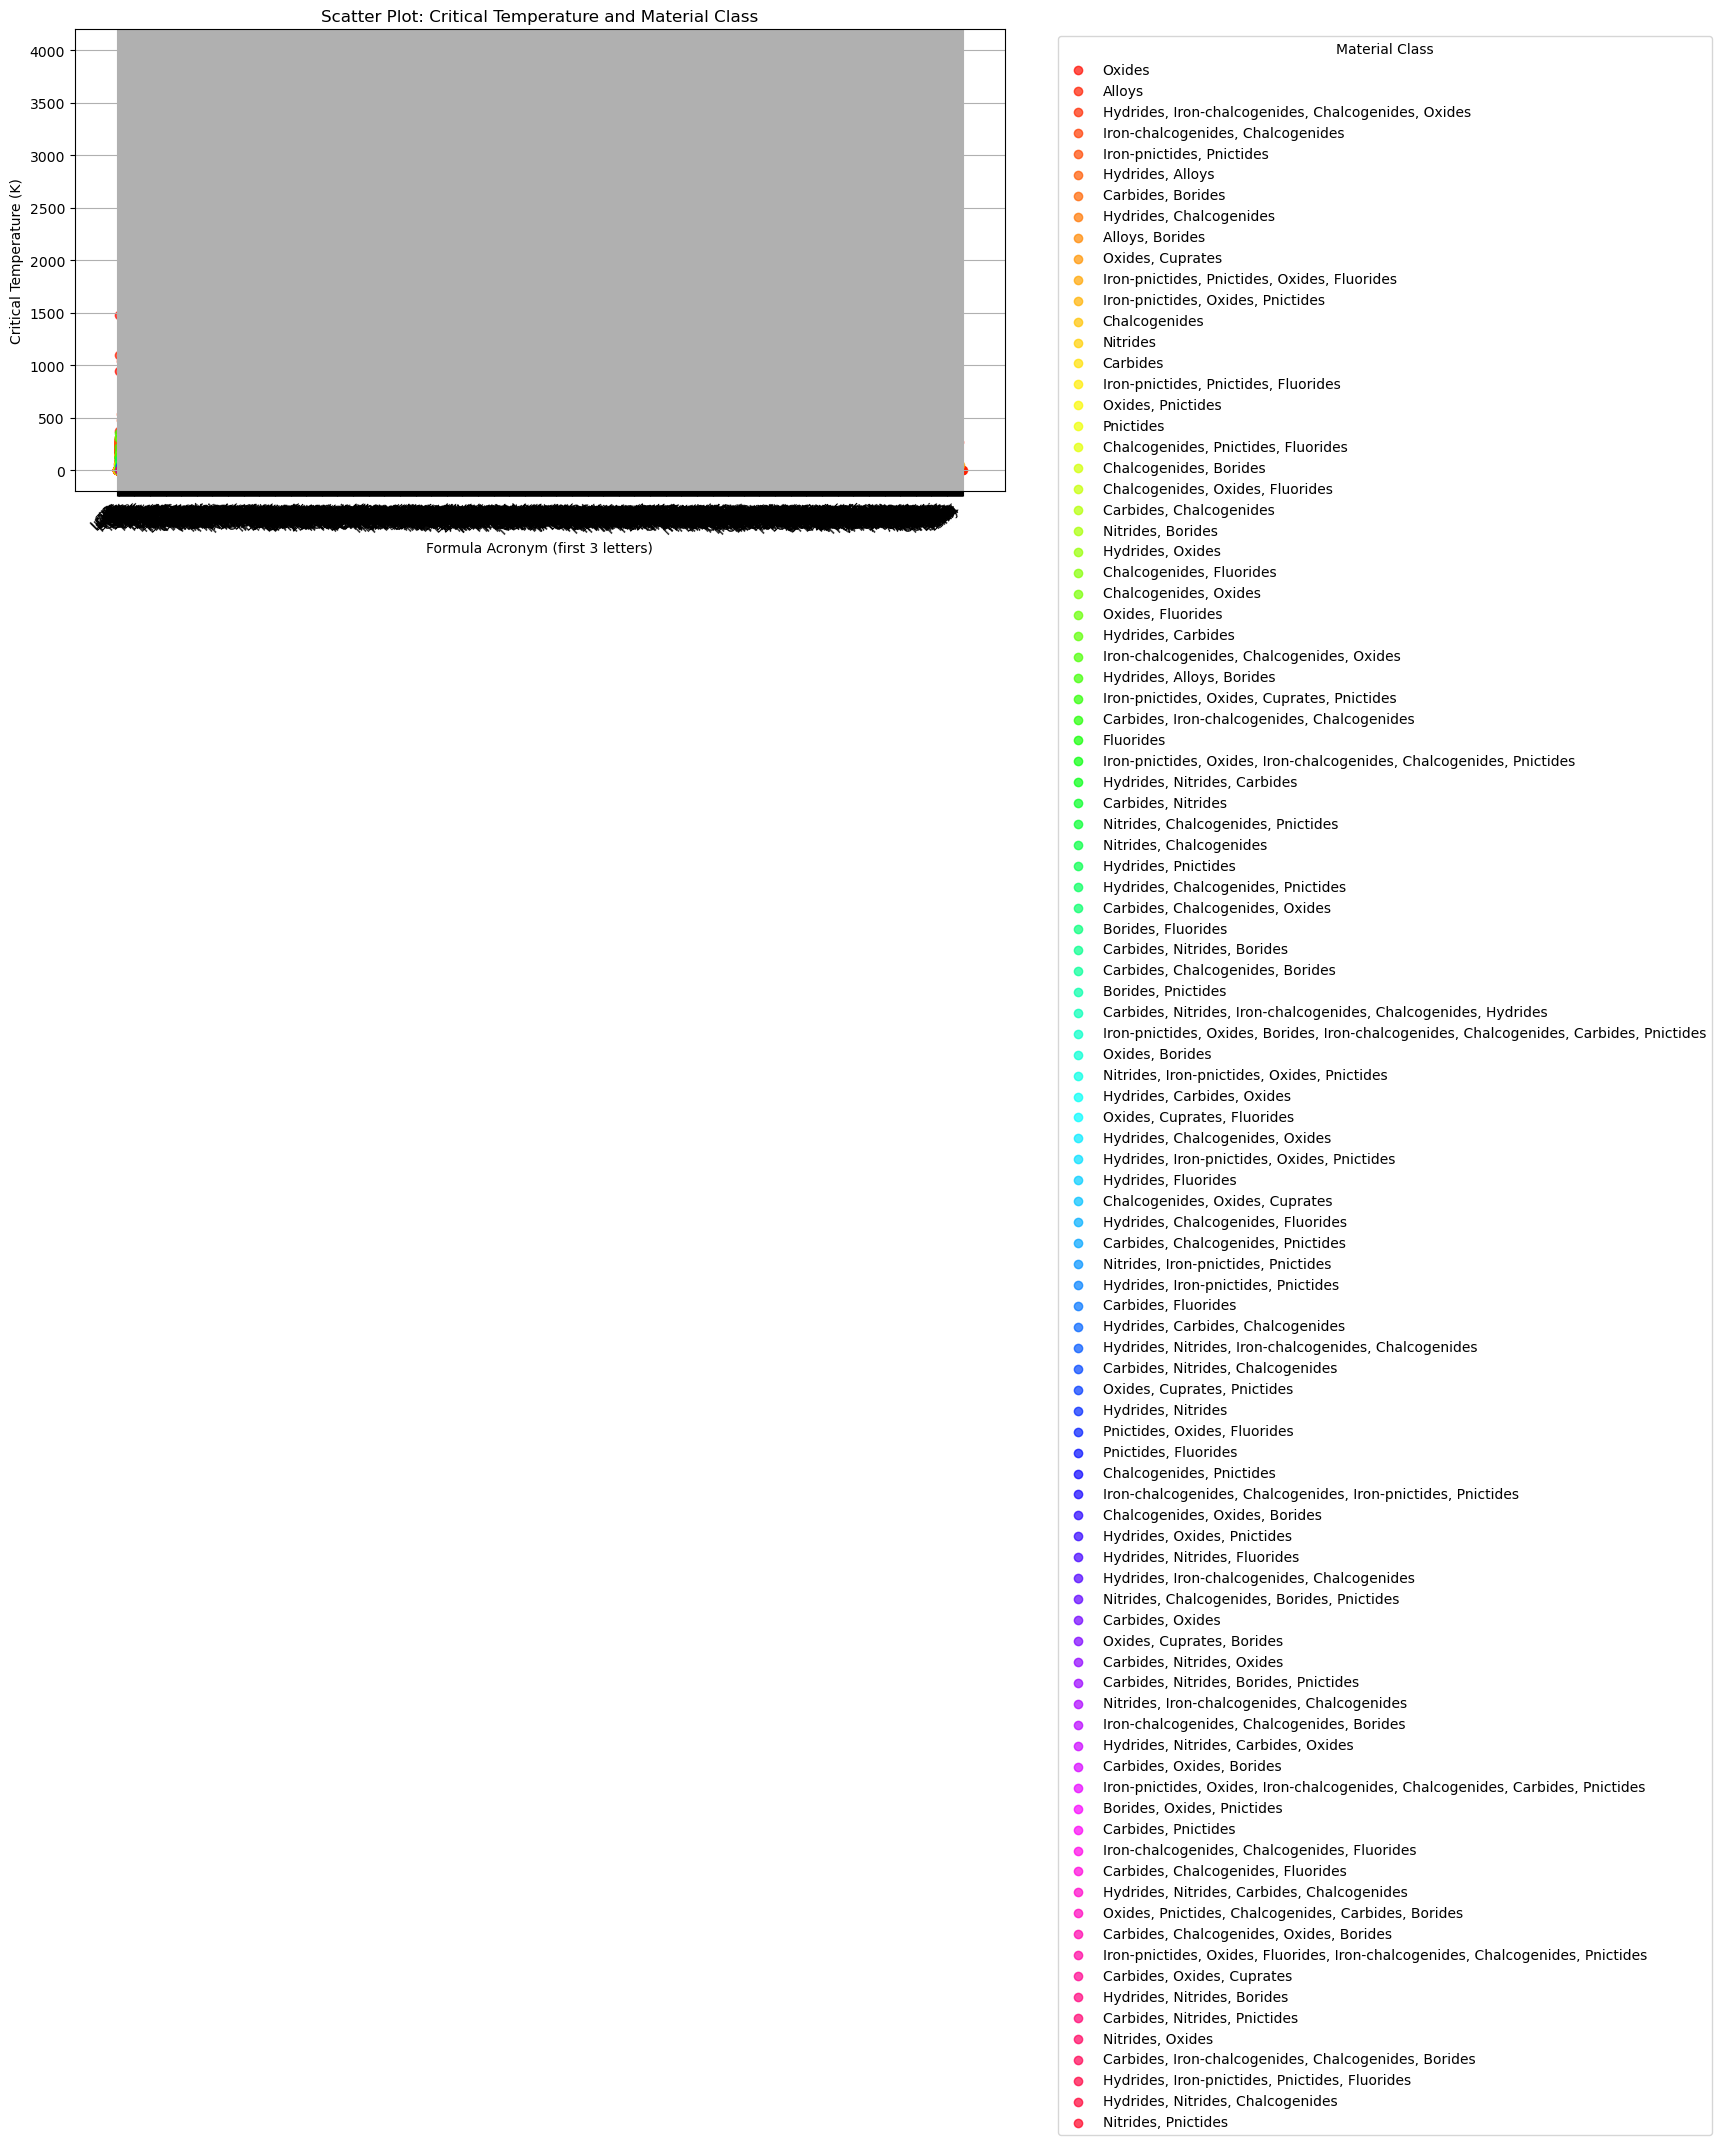

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

#To assign colors to each material class
classes = data['materialClass'].dropna().unique()
palette = sns.color_palette("hsv", len(classes))
colors = dict(zip(classes, palette))

# Function to get the first number from criticalTemperature?
def extract_first_number(s):
    if pd.isna(s):
        return None
    match = re.search(r"\d+\.?\d*", s)
    return float(match.group()) if match else None

# Convert criticalTemperature to numeric
data['criticalTemperature_numeric'] = data['criticalTemperature'].apply(extract_first_number)

# Filter out rows without formulas or critical temperatures
plot_data = data.dropna(subset=['formula', 'criticalTemperature_numeric'])

# Generate acronyms for formulas 
def formula_to_acronym(formula):
    if pd.isna(formula):
        return ""
    acronym = ''.join([word[0] for word in re.findall(r'[A-Za-z]+', formula)])  #take first letters of each word
    return acronym[:3]  # take only first 3 letters

plot_data['formula_acronym'] = plot_data['formula'].apply(formula_to_acronym)

# Map acronyms to numeric x-axis
acronyms_order = plot_data['formula_acronym'].unique()
acronym_to_x = {f: i for i, f in enumerate(acronyms_order)}

plt.figure(figsize=(12,6))
for mat_class in classes:
    subset = plot_data[plot_data['materialClass'] == mat_class]
    x_vals = subset['formula_acronym'].map(acronym_to_x)
    y_vals = subset['criticalTemperature_numeric']
    plt.scatter(
        x_vals,
        y_vals,
        c=[colors[mat_class]],
        label=mat_class,
        alpha=0.7
    )

# X-axis labels
plt.xticks(ticks=list(acronym_to_x.values()), labels=list(acronym_to_x.keys()), rotation=45, ha='right')

# Labels and title
plt.xlabel("Formula Acronym (first 3 letters)")
plt.ylabel("Critical Temperature (K)")
plt.title("Scatter Plot: Critical Temperature and Material Class")
plt.grid(True)

# Legend outside
plt.legend(title="Material Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




#issue: graph is blocked 

In [20]:
df = pd.read_csv('supercon1/data/001005fig1.csv')    #reads a csv file into a Dataframe(table in python)
df
data = pd.read_csv('supercon1/data/001005fig1.csv', header=5)    #use row 6, created a dataframe called data

data

,T (K),M (10-4 emu/g)
0,1.81590,-1.025000
1,1.89958,-0.850000
2,2.02510,-0.663333
3,2.17155,-0.449444
4,2.33891,-0.235556
...,...,...
100,9.15900,0.001667
101,9.53556,0.017222
102,9.61925,-0.013889
103,9.93305,0.005556


     T (K)  M (10-4 emu/g)
0  1.81590       -1.025000
1  1.89958       -0.850000
2  2.02510       -0.663333
3  2.17155       -0.449444
4  2.33891       -0.235556


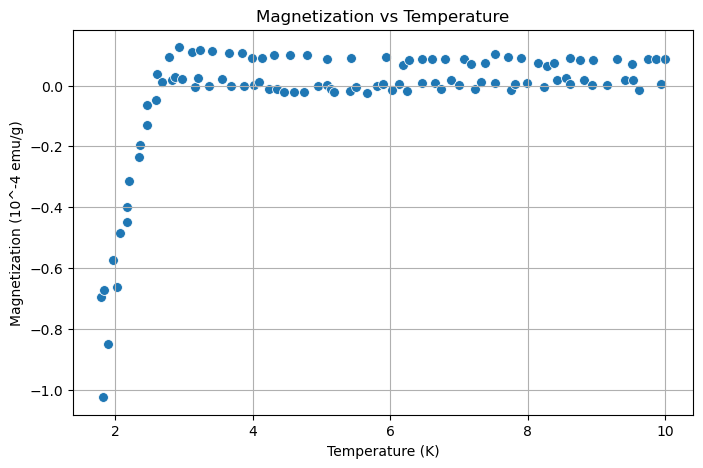

In [21]:

# Read CSV (header row is row 6, so header=5)
data = pd.read_csv('supercon1/data/001005fig1.csv', header=5)

# Inspect the data
print(data.head())

# Create scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='T (K)', y='M (10-4 emu/g)', s=50)  # s sets marker size
plt.xlabel('Temperature (K)')
plt.ylabel('Magnetization (10^-4 emu/g)')
plt.title('Magnetization vs Temperature')
plt.grid(True)
plt.show()

#mass magnetization

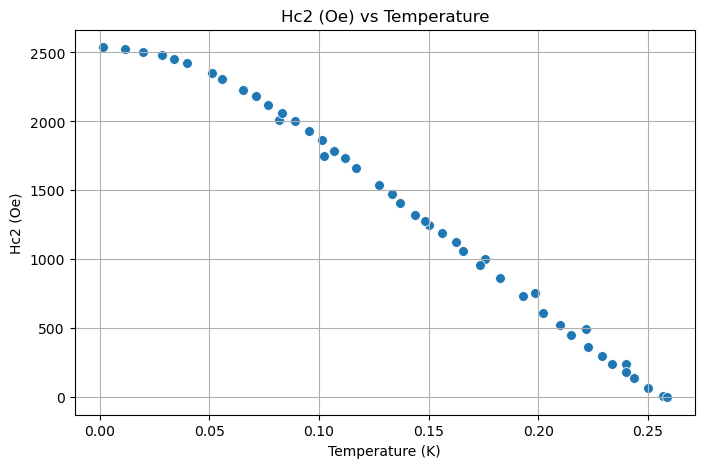

In [22]:
# Read CSV, skip comments and extra columns

d2 = pd.read_csv('supercon1/data/001005fig2.csv', header=3, usecols=[0,1])    #use row 6, created a dataframe called data, only use columns 1-2  

d2

# Create scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=d2, x='T (K)', y='Hc2 (Oe)', s=50)  # s sets marker size
plt.xlabel('Temperature (K)')
plt.ylabel('Hc2 (Oe)')
plt.title('Hc2 (Oe) vs Temperature')
plt.grid(True)
plt.show()



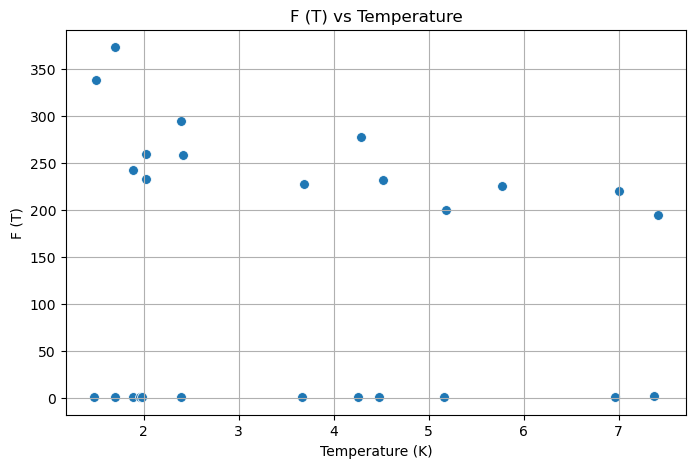

In [23]:
# Read CSV, skip comments and extra columns

d3 = pd.read_csv('supercon1/data/001006fig1.csv', header=4, usecols=[0,1])    #use row 6, created a dataframe called data, only use columns 1-2  

d3

# Create scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=d3, x='Tc (K)', y='F (T)', s=50)  # s sets marker size
plt.xlabel('Temperature (K)')
plt.ylabel('F (T)')
plt.title('F (T) vs Temperature')
plt.grid(True)
plt.show()

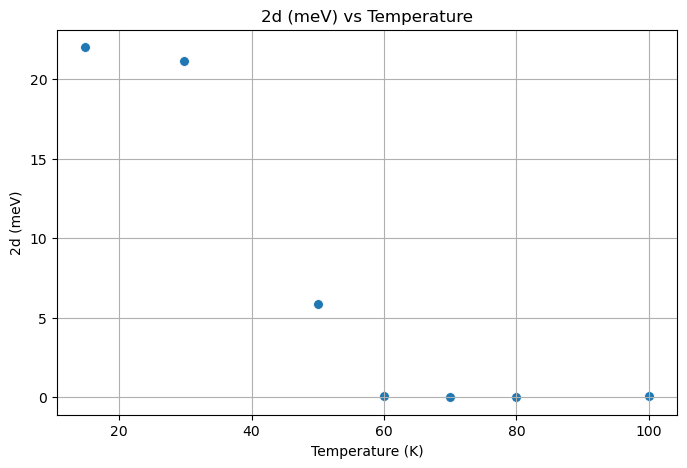

In [24]:
d4 = pd.read_csv('supercon1/data/1010fig1.csv', header=3, usecols=[0,1])    #use row 6, created a dataframe called data, only use columns 1-2
d4

# Create scatter plot
plt.figure(figsize=(8,5))                                               
sns.scatterplot(data=d4, x='Temperature (K)', y='2d (meV)', s=50)  # s sets marker size
plt.xlabel('Temperature (K)')
plt.ylabel('2d (meV)')
plt.title('2d (meV) vs Temperature')
plt.grid(True)                          
plt.show()



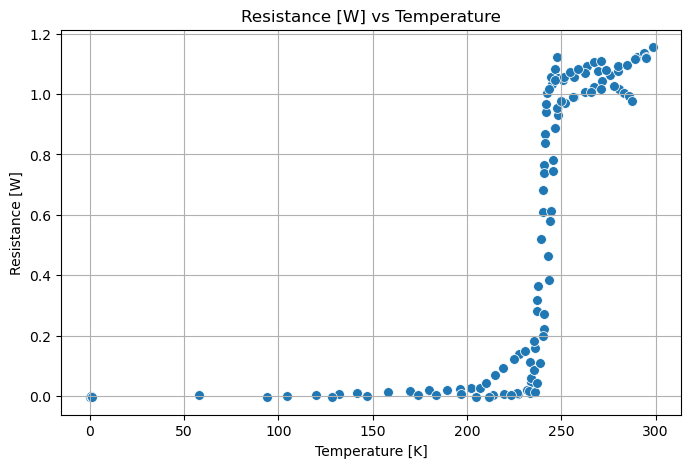

In [25]:
d5 = pd.read_csv('supercon1/data/158881fig1.csv', header=3, usecols=[0,1])    #use row 6, created a dataframe called data, only use columns 1-2

d5
# Create scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=d5, x='Temperature [K]', y='Resistance [W]', s=50)  # s sets marker size
plt.xlabel('Temperature [K]')
plt.ylabel('Resistance [W]')
plt.title('Resistance [W] vs Temperature')                   
plt.grid(True)
plt.show()



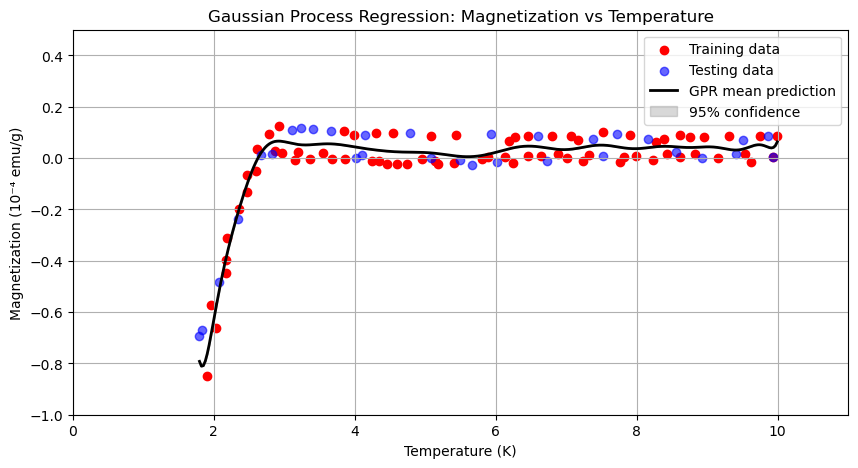

In [26]:
#Next step: modeling relationships
#train a model that mathematically captures the relationship between the inputs (features) and the output (target).
#first option: Gaussian Process Regression

#gaussian process regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import train_test_split

#Load CSV file
data = pd.read_csv('supercon1/data/001005fig1.csv', header=5)


X = data[['T (K)']].values       # must be 2D for sklearn
y = data['M (10-4 emu/g)'].values

#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Define kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0)

#Train GPR

#gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp = GaussianProcessRegressor(kernel=None).fit(X, y)
#gp.fit(X_train, y_train)

#Make predictions
x_pred = np.linspace(min(X), max(X), 300).reshape(-1, 1)
y_pred, sigma = gp.predict(x_pred, return_std=True)



#Plot results 
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, color='r', label='Training data')
plt.scatter(X_test, y_test, color='b', label='Testing data', alpha=0.6)
plt.plot(x_pred, y_pred, 'k', lw=2, label='GPR mean prediction')
plt.fill_between(x_pred[:, 0], y_pred - 1.96*sigma, y_pred + 1.96*sigma, 
                 color='gray', alpha=0.3, label='95% confidence')
plt.xlim(0, 11)      # Focus on the low-temperature region
plt.ylim(-1.0,.50) # Zoom in on the magnetization range
plt.xlabel('Temperature (K)')
plt.ylabel('Magnetization (10⁻⁴ emu/g)')
plt.title('Gaussian Process Regression: Magnetization vs Temperature')
plt.legend()
plt.grid(True)
plt.show()
